In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import scipy
from numba import njit

# IMPORT FROM OUR MODULE
import helpers as hp

from kneed import KneeLocator

# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)

/Users/miriamzara/ITI_GroupProject/helpers.py:107: SyntaxWarning: invalid escape sequence '\s'
  """


References:
-  "A Statistical Framework for Neuroimaging data Analysis Based on Mutual Information Estimated via a Gaussian Copula"
- [Finite Sample bias correction (Miller-Madow) for Discrete Shannon Entropy](https://arxiv.org/abs/cond-mat/0403192)


# **WHAT CAN MI ESTIMATE**
- MI between neural variable and an external signal
- MI between two neural variables
- Transfer entropy/Granger causality :: CMI between two neural variables

_NOTICE:_ The key idea is that MI should detect **any statistical dependence**. The main issue is how to estimate MI though. 

# **SIMULATED DATA**
1) Simulate an external signal $S(t)$ and a neural variable $X(t)$ with three different types of relation with or without lag. 

    Types: 
    - linear
    - monotonic non linear
    - non monotonic (quadratic for example)
 
2) Compute MI (with or without lag, and maybe conditioning on $X(t-1)$) with different methods. 
    
    Methods: 
    - Gaussian (assuming joint normality)
    - Binning 
    - KDE ** maybe ** 
    - Gaussian copula 

## Numba

---------------
**Note** some functions are written in Numba, a function compiler for accellerating Python code.

If you do not have it installed, you can get it with:


```{bash}
pip install numba
```

# Ground truth mi:

We will benchmark various estimators with repsect to the *true* value of the differential mutual information.


--------------

Gaussian variables, linear relation:

$$
S \sim \mathcal{N}(m, v^2),\quad  \eta \sim \mathcal{N}(0, 1), \quad X = S + \sigma \cdot \eta
$$

$$
mi(X:S)= \frac{1}{2}\log_2\left( 1 + \frac{v^2}{\sigma^2}\right)
$$

--------------

Numeric calculation of mi in the general case $X = f(S) + \sigma \cdot \eta$

$$
mi(X:S) = h(X) - h(X|S)
$$

while h(X|S) is analytical, provided f is monotonic (we are in a gaussian channel), h(X) is difficult to compute analytically. We resort to sampling combined with KDE (to estimate the pdf of X) and then perform numeric integration (to compute h(X)).

**Gaussian case: comparison of the analytical mi and the numeric mi (correctness check)**

entropy analytic: 2.547095585180641
entropy numeric: 2.556511804873843
mi analytic: 0.5
mi numeric: 0.5094162196932022


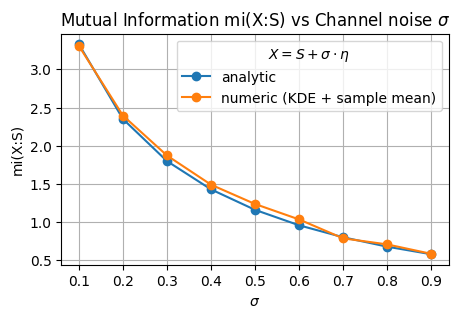

In [2]:
sigma_ = 1
numeric_hx = hp.entropy_monotonic_numeric(lambda s: s, sigma=sigma_)


print("entropy analytic:", hp.entropy_gaussian(np.sqrt(sigma_**2 + 1)))
print("entropy numeric:", numeric_hx)


numeric_mi = numeric_hx - hp.entropy_gaussian(sigma_)

print("mi analytic:", hp.mi_gaussian_analytic(sigma_**2))
print("mi numeric:", numeric_mi)



sigma_vec = np.arange(0.1, 1, 0.1)
numeric_mi = [hp.entropy_monotonic_numeric(lambda s: s, sigma=sigma) - hp.entropy_gaussian(sigma) for sigma in sigma_vec]
analytic_mi = [hp.mi_gaussian_analytic(sigma**2) for sigma in sigma_vec]

fig ,ax = plt.subplots(figsize = (5, 3))
ax.plot(sigma_vec, analytic_mi, marker = "o",  label = "analytic")
ax.plot(sigma_vec, numeric_mi, marker = "o", label = "numeric (KDE + sample mean)")
ax.grid()
ax.legend(title = r"$X = S + \sigma \cdot \eta$")
ax.set_title(r"Mutual Information mi(X:S) vs Channel noise $\sigma$")
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel("mi(X:S)")
plt.show()


Text(0, 0.5, 'mi(X:S)')

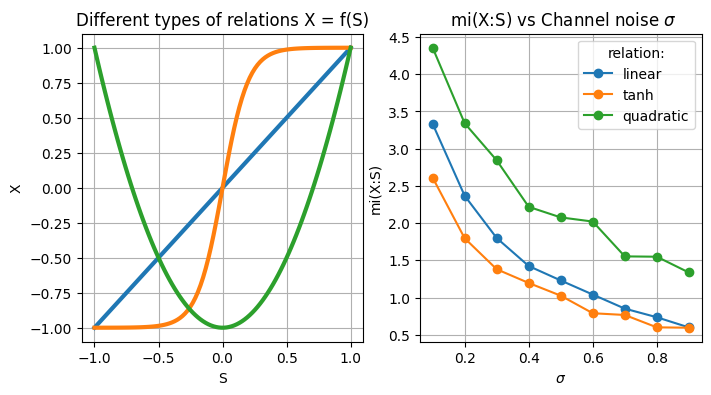

In [3]:
S = np.linspace(-1, +1, 100)

relations_dict = {"linear": lambda s: s,
                "tanh": lambda s: np.tanh(5*s),
                "quadratic": lambda s: 2 * s**2 - 1}


mi_trends = []
for key, f in relations_dict.items():
   mi_trends.append([hp.entropy_monotonic_numeric(f, sigma=sigma) - hp.entropy_gaussian(sigma) for sigma in sigma_vec])



X = np.vstack([hp.generate_neural_variable(S, f = relations_dict["linear"], noise_std = 0),
            hp.generate_neural_variable(S, f = relations_dict["tanh"], noise_std = 0),
            hp.generate_neural_variable(S, f = relations_dict["quadratic"], noise_std = 0)])


fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))



for i, key in enumerate(relations_dict.keys()):
    axs[0].plot(S, X[i, :], label = key, lw = 3)
    axs[1].plot(sigma_vec, mi_trends[i], marker = "o", label = key)


axs[0].set_xlabel("S")
axs[0].set_ylabel("X")
axs[0].set_title("Different types of relations X = f(S)")
axs[0].grid()



axs[1].grid()
axs[1].legend(title = "relation:")
axs[1].set_title(r" mi(X:S) vs Channel noise $\sigma$")
axs[1].set_xlabel(r"$\sigma$")
axs[1].set_ylabel("mi(X:S)")

**Examples of syntethic data**


Let's start simple! We generate an external signal $S(t) \sim \mathcal{N}(0,1)$ (i.i.d. random variables, no temporal structure). 

On that we generate the neural variable: $X(t) = f(S(t)) + \eta(t)$, with $\eta(t) \sim \mathcal{N}(0,\sigma^2)$ being the additional noise.  


- linear

    $$
    X(t) = S(t) + \sigma \cdot \eta(t)
    $$

- monotonic, non linear
    $$
    X(t) = S(t)^3 + \sigma \cdot \eta(t)
    $$

    OR 

    $$
    X(t) = \tanh[S(t)] + \sigma \cdot \eta(t)
    $$

    _NOTICE_: tanh is nice because it is smooth and monotonically increasing as the cubic, but it is also saturating (thus "neuron-like" and not exploding numerically). 


- Non-monotonic 
    $$
    X(t) = S(t)^2 + \sigma \cdot \eta(t)
    $$

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_2557/2463511385.py:20: SyntaxWarning: invalid escape sequence '\s'
  hp.plot_joint_distribution_sns(S, X_linear, title_string = f"$\sigma = {sigma_}, N = {Ntsteps}$")


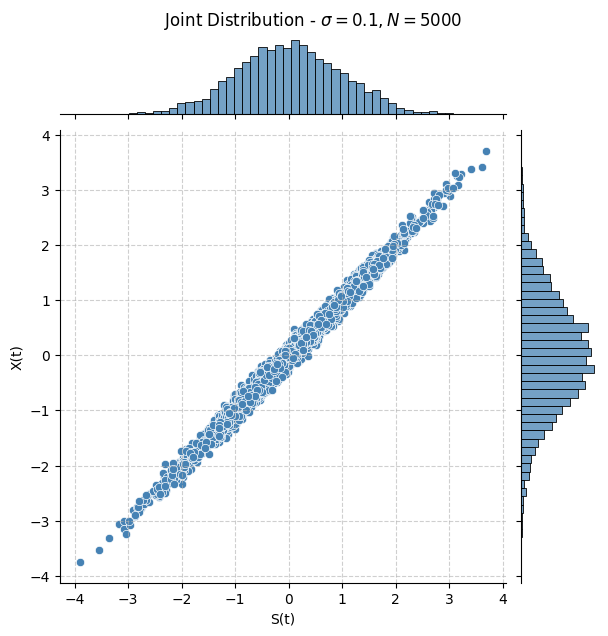

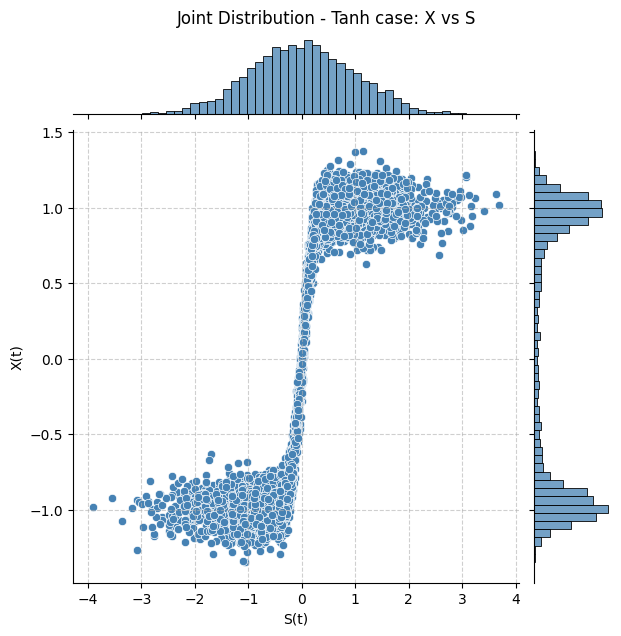

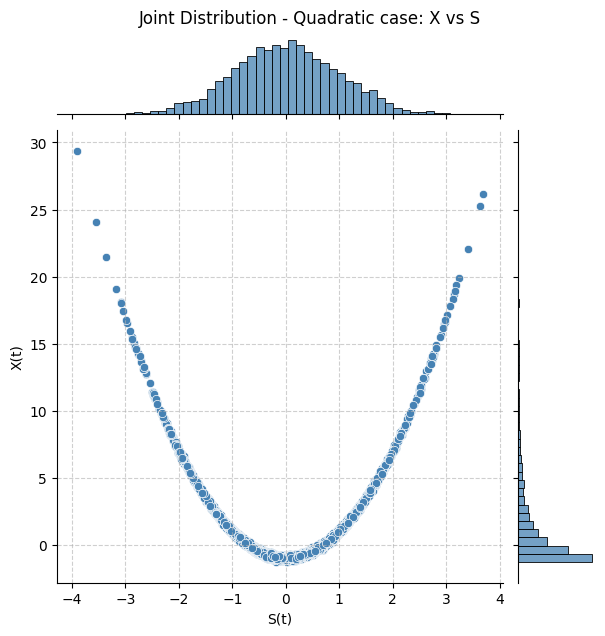

In [4]:
Ntsteps = 5000
sigma_ = 0.1
S = np.random.normal(0, 1, Ntsteps)



# ------ Linear, no AR, no LAG ------------
X_linear = hp.generate_neural_variable(S, f= lambda s: s, noise_std = sigma_) # --> we can change also the noise strength from here directly! (Default is 1)
# ------ Linear, no AR, LAG of 2 ---------------
# X_linear = hp.generate_neural_variable(S, lag = True, tau = 2)
# ------ Linear, AR, no LAG ---------------
# X_linear = hp.generate_neural_variable(S, auto_regr=True)

#hp.plot_ts(X_linear, r"$X(t) = a\,S(t) + \eta$, a = 1", color = "forestgreen") # no autoregression and no temporal structure of S(t), so there is no need to plot the time series
#hp.plot_hist(X_linear, r"$X(t) = a\,S(t) + \eta$, a = 1", xlabel = "X", color = "forestgreen")
#hp.plot_joint_distribution(S, X_linear, 
#                           title_string="Linear case: X vs S",
#                           color="forestgreen") #, density = True)

hp.plot_joint_distribution_sns(S, X_linear, title_string = f"$\sigma = {sigma_}, N = {Ntsteps}$")


# ------ Tanh, no AR, no LAG ------------
X_tanh = hp.generate_neural_variable(S, f= lambda s: np.tanh(5*s), noise_std = sigma_)
hp.plot_joint_distribution_sns(S, X_tanh, title_string = "Tanh case: X vs S")


X_quad = hp.generate_neural_variable(S, lambda s: 2*s**2 - 1, noise_std = sigma_)
hp.plot_joint_distribution_sns(S, X_quad, title_string = "Quadratic case: X vs S")

## BINNING METHOD

Leaving aside the problem posed by the *curse of dimensionality*, the binning method has some challenges even in the simplest, 2d case:

1. **Bin Number choice**
    - too few bins -> the discretized MI is not a good approximation of the true mi
    - too many bins -> we are fitting noise


    How do we understand if the bin choice is good, considered that, in practice, we usually have a single data sample, of fixed (possibly low) size?

2. **Uncertainty Estimation**
    Given that the estimate of mi contains dependence on the dataset, can we associate a measure of statistical uncertainty to it?




    A possibility is to do **bootstrapping**: 
    - draw $n<N$ samples from the dataset (with replacement)
    - estimate the mi
    - repeat for a large number of times
    - compute the empirical standard deviation

### Choosing the optimal number of bins

In [10]:
# ------ Linear case f(s)= s --------------



sigma_ = 0.1
ground_truth_mi = hp.mi_gaussian_analytic(sigma_**2)
N = 1000
M = 10

bins = np.arange(10, 500, 2)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = hp.generate_data(N, sigma_)
    for idx, bin in enumerate(bins):
        results[m, idx] = hp.mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = hp.histogram_error_numba(data[:, 1], bin)


avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)



# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'
kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")

#kn.plot_knee()

Optimal number of bins: (68, 29)


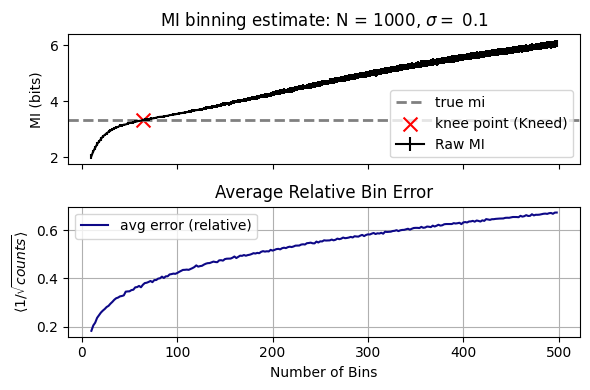

In [13]:
colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label='Raw MI')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

Empirical observation: the true value of m.i. seems to corresponds to a knee point of the mi estimate obtained through binning.


 -> This could be a possible cryterion for choosing the optimal bin number.



Let us now systematically check how this cryterion performs, at varying sample size (N) and channel noise ($\sigma$).

In [11]:
sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.])
N_vec = np.array([100, 200, 500, 1000, 2000, 5000])
M = 10

estimates = np.empty(shape = (len(sigma_vec), len(N_vec), M))



true_mi_vec = np.array([hp.mi_gaussian_analytic(s**2) for s in sigma_vec])

for i, sigma in enumerate(sigma_vec):
    for j, N in enumerate(N_vec):

        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)
        
        for k in range(M):
            data = hp.generate_data(N, sigma)
            
            # Vectorized MI calculation
            y = np.array([hp.mi_binning_2d_numba(data, b) for b in bins])

            kn = KneeLocator(bins, y, S=1.0, curve='concave', direction='increasing')
            
            estimates[i, j, k] = np.nan
            if kn.knee:
                knee_idx = np.argwhere(bins == kn.knee)[0][0]
                estimates[i, j, k] = y[knee_idx]


avg_estimates = np.mean(estimates, axis=2)
relative_errors = np.abs((avg_estimates - true_mi_vec[:, np.newaxis]) / true_mi_vec[:, np.newaxis])

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_2557/3775704082.py:21: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel("Channel Noise ($\sigma$)")


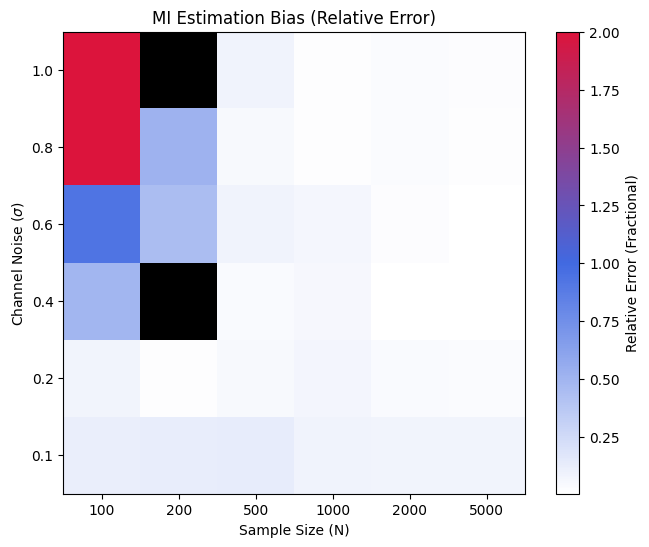

In [12]:
colors = ["white", "royalblue", "crimson"] 
nodes = [0.0, 0.5, 1.0]
my_cmap = LinearSegmentedColormap.from_list("my_custom_scale", list(zip(nodes, colors)))
my_cmap.set_bad(color = "black")



fig, ax = plt.subplots(figsize=(8, 6))

relative_errors_clipped = np.clip(relative_errors, a_min = 0, a_max = 2)
im = ax.imshow(relative_errors_clipped, cmap=my_cmap, origin = "lower")
cbar = fig.colorbar(im)
cbar.set_label('Relative Error (Fractional)')

ax.set_xticks(np.arange(len(N_vec)))
ax.set_xticklabels(N_vec)
ax.set_yticks(np.arange(len(sigma_vec)))
ax.set_yticklabels(sigma_vec)

ax.set_xlabel("Sample Size (N)")
ax.set_ylabel("Channel Noise ($\sigma$)")
ax.set_title("MI Estimation Bias (Relative Error)")

plt.show()

Works pretty well... but will it work also for other kind of relationships f(S)?

Optimal number of bins: (26, 8)


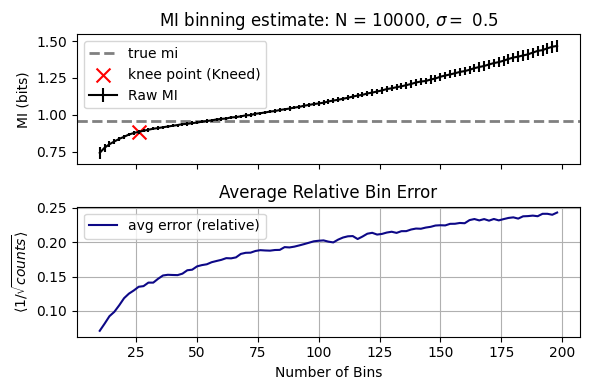

In [23]:
# ---- Function: tanh -----------
f = relations_dict["tanh"]


sigma_ = 0.5
ground_truth_mi = hp.mi_monotonic_numeric(f, N_large = 10000, sigma = sigma_)


N = 10000
M = 10

bins = np.arange(10, 200, 2)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = hp.generate_data(N, sigma_, f)
    for idx, bin in enumerate(bins):
        results[m, idx] = hp.mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = hp.histogram_error_numba(data[:, 1], bin)


avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)



# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'
kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")

#kn.plot_knee()



colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label='Raw MI')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

More or less...

<>:61: SyntaxWarning: invalid escape sequence '\s'
<>:61: SyntaxWarning: invalid escape sequence '\s'
/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_2557/1602499923.py:61: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel("Channel Noise ($\sigma$)")


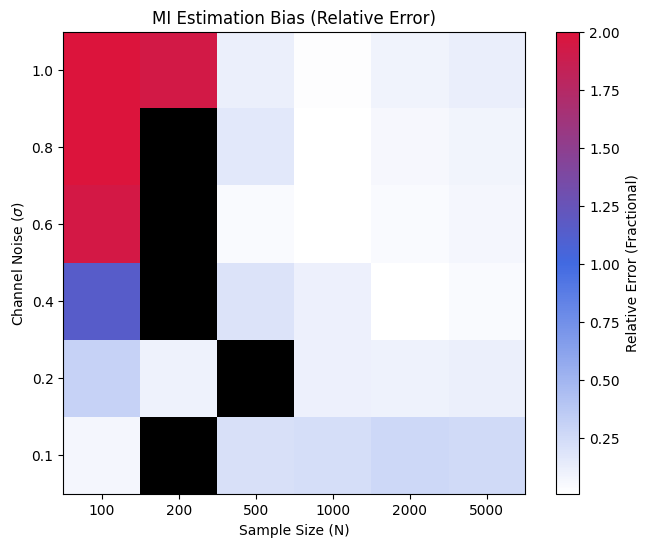

In [24]:
# ------------
f = relations_dict["tanh"]


sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.])
N_vec = np.array([100, 200, 500, 1000, 2000, 5000])
M = 10

estimates = np.empty(shape = (len(sigma_vec), len(N_vec), M))

true_mi_vec = np.array([hp.mi_monotonic_numeric(f, N_large = 10000, sigma = s) for s in sigma_vec])
# ---------------



for i, sigma in enumerate(sigma_vec):
    for j, N in enumerate(N_vec):

        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)
        
        for k in range(M):
            data = hp.generate_data(N, sigma, f)
            
            # Vectorized MI calculation
            y = np.array([hp.mi_binning_2d_numba(data, b) for b in bins])

            kn = KneeLocator(bins, y, S=1.0, curve='concave', direction='increasing')
            
            estimates[i, j, k] = np.nan
            if kn.knee:
                knee_idx = np.argwhere(bins == kn.knee)[0][0]
                estimates[i, j, k] = y[knee_idx]


avg_estimates = np.mean(estimates, axis=2)
relative_errors = np.abs((avg_estimates - true_mi_vec[:, np.newaxis]) / true_mi_vec[:, np.newaxis])


colors = ["white", "royalblue", "crimson"] 
nodes = [0.0, 0.5, 1.0]
my_cmap = LinearSegmentedColormap.from_list("my_custom_scale", list(zip(nodes, colors)))
my_cmap.set_bad(color = "black")



fig, ax = plt.subplots(figsize=(8, 6))

relative_errors_clipped = np.clip(relative_errors, a_min = 0, a_max = 2)
im = ax.imshow(relative_errors_clipped, cmap=my_cmap, origin = "lower")
cbar = fig.colorbar(im)
cbar.set_label('Relative Error (Fractional)')

ax.set_xticks(np.arange(len(N_vec)))
ax.set_xticklabels(N_vec)
ax.set_yticks(np.arange(len(sigma_vec)))
ax.set_yticklabels(sigma_vec)

ax.set_xlabel("Sample Size (N)")
ax.set_ylabel("Channel Noise ($\sigma$)")
ax.set_title("MI Estimation Bias (Relative Error)")

plt.show()

## KDE METHOD

$$
mi(X:S) = [h(X) + h(S)] - h(X, S) = \int \,dx\,ds \,\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}  \cdot f(s, x)
$$

Use KDE to estimate the three underlying pdfs (the two marginals and the joint). Then draw a large number of samples from the estimated joint pdf, and return 

$$
mi(X:S) \simeq \mathbb{E}[\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}]
$$

In [2]:
# --- Linear case ---
N = 1000
sigma_ = 0.1
data = hp.generate_data(N, sigma_)
true_mi = hp.mi_gaussian_analytic(sigma_**2)

print("Analytical MI:" , true_mi)
print("KDE estimated MI:" , hp.estimate_mi_kde(data))

Analytical MI: 3.3291057413758973
KDE estimated MI: 3.3819014770997664


In [3]:
# Performance at varying N
N_vec = np.floor(np.logspace(1, 4, base = 10, num = 10)).astype(int)
sigma_ = 0.1
M = 1

kde_estimates = []

for N in N_vec:
    mean = 0
    for realization in range(M):
        data = hp.generate_data(N, sigma_)
        mean += hp.estimate_mi_kde(data)
    mean /= M
    kde_estimates.append(mean)

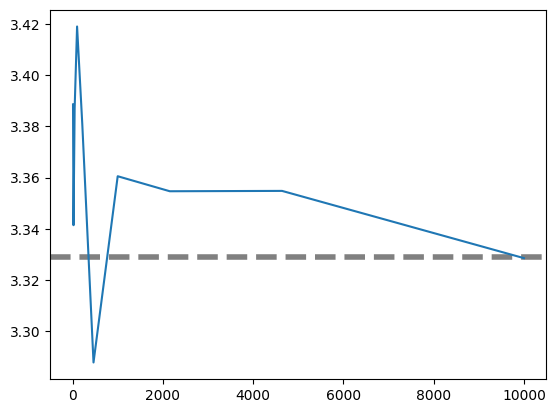

In [4]:
fig, ax = plt.subplots()
ax.axhline(true_mi, color = "grey", linestyle = "dashed", linewidth = 4)
ax.plot(N_vec, kde_estimates)

# ESTIMATING MI FROM SIMULATED DATA

Comparison of various methods with the **ground truth**. Analyzed methods are:

1. binning (parameter: $\epsilon$ - bin width)
2. KDE (parameter: $v^2$ kernel smoothness)
3. Gaussian Copula (parameters: none)


Analysis of dependence of the relative error upon:

- amplitude of the stochastic noise, $\sigma^2$
- number of data samples, $N$.

## Ground truth calculations



**Relations between the differential quantities:**

At difference with the discrete case, the differential entropy is not invariant under a monotonic transformation. 


- If X = f(S) with f monotonic, it holds that:

    $$
    h(X) = h(S) + \mathbb{E}\left[\ln |f'(S)|\right]
    $$

- If $X = f(S) + \sigma \cdot \eta$ with f monotonic (**Gaussian noisy channel**), it is not possible to compute analytically the entropy of X, except for a few special cases (gaussian S and linear f)

    $$
    h(X) = h(f(S) + \eta )  = \mathbf{?}
    $$

    Therefore, we need to resort to **numeric integration** to have a ground truth value for h(X).

.

.

.



Also, at difference with the discrete case, it is no longer true that if $X = f(S)$, then $h(X|S) = 0$. Instead, if $X= f(S)$ it holds that $h(X|S) = - \infty$.

To work with finite numbers, it is convenient to add some noise $X =  f(S) + \sigma \cdot \eta$, so that $h(X|S)$ is the differential entropy of a normal variable, 

$$
h(X|S) = \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma^2]
$$

.

.

.


Putting everything together, the differential mutual information will be given by:

$$
mi(X:S) = h(X) - h(X|S) \simeq \left[ h(X)^{num} \right] - \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma^2] \geq 0
$$

where $h(X)^{num}$ is an estimate obtained through numeric integration or montecarlo.


$mi(X:S)\geq 0$ always and $mi(X:S)\rightarrow +\infty$ for $\sigma \rightarrow 0$ (deterministic case). 


This actually makes sense, although can be a little confusing:

*Because S is a continuous variable, it technically contains an infinite amount of information (it takes an infinite number of decimal places to specify its exact value). If X=f(S) and f is monotonic, then knowing S tells you X with infinite precision. Therefore, the information they share is infinite.*

-------------------------

**Channel capacity of a Gaussian channel**

Since we are generating the response variable adding a gaussian white noise, $X = f(S) + \sigma \cdot \eta$, we are inside the framework of a gaussian noisy channel. The differential mutual information between X and S depends on i) the distribution of the source, ii) the functional form of f, but in any case it is upper bounded by the channel capacity.

.

.


Restricting to source variables $Z=f(S)$ with $E[Z] = 0, E[z^2] \leq v^2$


$$
0 \leq mi(X:Z) \leq C = max_{p(Z)} \left\{mi(X:Z)\right\} = \frac{1}{2} \log_2 [1 + \left(\frac{v}{\sigma}\right)^2]
$$

In particular:

- if S is normally distributed and $f$ is a linear function, then  also Z is normally distributed, and the mi between X and Z ($\equiv mi(X:S)$) is the channel capacity.

-------------------------

In [ ]:
S = np.random.normal(0, 1, Ntsteps)


## Binning

We are interested in estimating the *differential mutual information (mi)* between the continuous r.v.s. X and S. The *binning* method makes use of this fact:





If X, S are the continuous r.v.s and $X_\epsilon, S_\epsilon$ are their discretized (binned) versions,

$$
lim_{\epsilon \rightarrow 0^+} MI(X_{\epsilon}: S_{\epsilon}) = mi(X, S)
$$



-------------------
**Relations between the discretized quantities:**

 - If X is a deterministic function of S, $H(X_\epsilon|S_\epsilon) = 0$. Hence:

    $$
    MI(X_{\epsilon}: S_{\epsilon}) = H(X_{\epsilon}) - H(X_\epsilon|S_\epsilon) \equiv  H(X_{\epsilon})
    $$

    Entropies of the response X and the source S are linked by the *data processing inequality*, which states that:

    $$
    \text{if} \quad X = f(S), \quad \text{then} \quad H(X) \leq H(S)
    $$


    In particular, if $f$ is a **bijective** function, $H(X) \equiv H(S)$. In this case, therefore, 

    $$
    MI(X_{\epsilon}: S_{\epsilon}) = H(S_{\epsilon}).
    $$


-------------------------
Differential entropy of a gaussian r.v.

$$
h(S) = \frac{1}{2} \log_2 [(2\pi e) \cdot \sigma_S^2]
$$

$$
H(S_\epsilon) = h(S) + \log_2\left(\frac{1}{\epsilon}\right) + \mathcal{O}(\epsilon)
$$

-------------------------


## M.I. ASSUMING JOINT NORMALITY
If $X$ and $S$ are jointly Gaussian, the mutual information is: 
$$
I(X; S) = - \frac{1}{2}\log_2(1 - \rho^2)
$$
where: 
$$
\rho = corr(X,S) \text{\ \ is the Pearson correlation coefficient}. 
$$

_NOTICE:_ 
A pair (U,V) is jointly Gaussian if EVERY LINEAR COMBINATION of aU+bV is Gaussian ($\forall a, b \in \mathbb{R}$). Thus, having U and V Gaussian is not sufficient (although necessary): you need independence OR a known linear relationship to guarantee joint Gaussianity. 

This is why in our linear case MI is correct, while in the other cases it may be non-zero but not-exact or even not capture any correlation at all, even though correlations are present. 

In [ ]:
# Example: 
mi_linear = hp.gaussian_mi(X_linear, S)
print(f"MI (linear) = {mi_linear:.3f} bits")

mi_cub = hp.gaussian_mi(X_cub, S)
print(f"MI (cubic) ≈ {mi_cub:.3f} bits (Gaussian approx)")

mi_tanh = hp.gaussian_mi(X_tanh, S)
print(f"MI (tanh) ≈ {mi_tanh:.3f} bits (Gaussian approx)")

mi_quad = hp.gaussian_mi(X_quad, S)
print(f"MI (quad) ≈ {mi_quad:.3f} bits (Gaussian approx)")

AttributeError: module 'helpers' has no attribute 'gaussian_mi'

**NOTICE:**
Variations (maybe in some sistematic way) can be tried and commented (as for considering AR or lag presence cases). 

# **TO THINK AND MAYBE GO ON FROM HERE** ... do we have a way to compute the exact (analytical) MI to compare with Gaussian MI here?

# **REAL DATA**